<a href="https://colab.research.google.com/github/nilum2002/EN3150-Pattern-Recognition/blob/main/Answers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pattern Recognition Assinment 01 - 230415H

Q1 -  Code workings

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

def generate_features(n_sapmples=1000, student_id=123456):

    np.random.seed(student_id%1000)

    # feature 1: normal distribution data
    feature_1 = np.random.normal(loc=50, scale=15, size=n_sapmples)

    # feature 2: Exponential distribution data (highly skewed)
    feature_2 = np.random.exponential(scale=2, size=n_sapmples)

    # Include a few extream artificial outliers in feature 2
    feature_2[np.random.choice(n_sapmples, 5, replace=False)] = np.random.uniform(50, 100, 5)

    return feature_1, feature_2


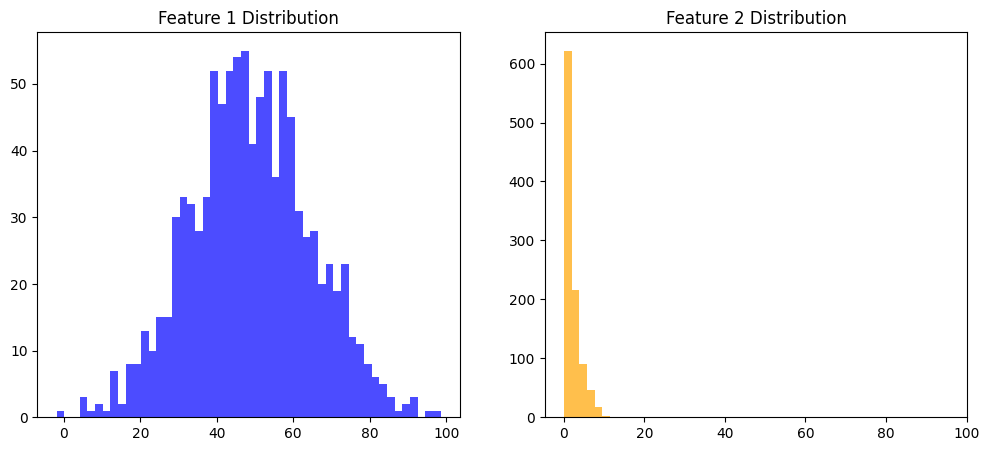

In [4]:
student_id = 230415
f1, f2 = generate_features(n_sapmples=1000, student_id=student_id)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(f1, bins=50, color='blue', alpha=0.7) # histogram for feature 1
plt.title('Feature 1 Distribution')
plt.subplot(1, 2, 2)
plt.hist(f2, bins=50, color='orange', alpha=0.7) # histogram for feature 2
plt.title('Feature 2 Distribution')
plt.show()

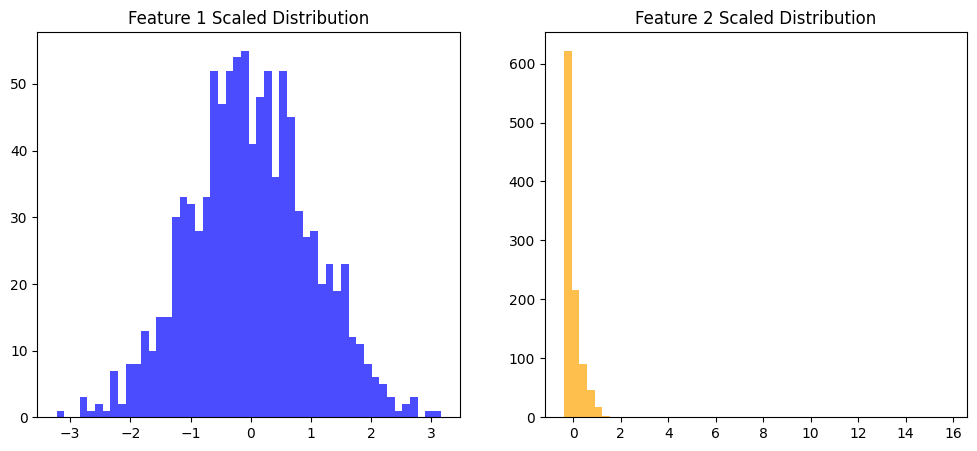

In [5]:
######################################################################
##              Sample Standardization of Features                  ##
######################################################################
standard_scaler = StandardScaler()
f1_scaled = standard_scaler.fit_transform(f1.reshape(-1, 1)).flatten()
f2_scaled = standard_scaler.fit_transform(f2.reshape(-1, 1)).flatten()


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(f1_scaled, bins=50, color='blue', alpha=0.7) # histogram for feature 1
plt.title('Feature 1 Scaled Distribution')
plt.subplot(1, 2, 2)
plt.hist(f2_scaled, bins=50, color='orange', alpha=0.7) # histogram for feature 2
plt.title('Feature 2 Scaled Distribution')
plt.show()

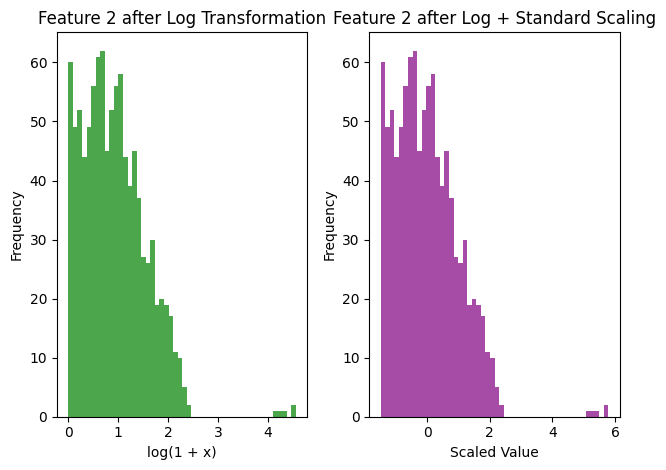

In [6]:
#######################################################################
##        Non Linear Transformations  - Log Transformation           ##
#######################################################################


f2_log   = np.log1p(f2)  # log(1 + x) to handle zero values since feature 2  values are close to zero
f2_scaled_log = standard_scaler.fit_transform(f2_log.reshape(-1, 1)).flatten()


plt.subplot(1,2,1)
plt.hist(f2_log, bins=50, color='green', alpha=0.7)
plt.title('Feature 2 after Log Transformation')
plt.xlabel('log(1 + x)')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
plt.hist(f2_scaled_log, bins=50, color='purple', alpha=0.7)
plt.title('Feature 2 after Log + Standard Scaling')
plt.xlabel('Scaled Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Q2 - Code Workings

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn import model_selection as model_selection
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
diabetes_dataset = load_diabetes(as_frame=True)

In [8]:
type(diabetes_dataset.data)

pandas.core.frame.DataFrame

In [9]:
diabetes_dataset.data.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [10]:
diabetes_dataset.target.head()

,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


In [11]:
diabetes_dataset.frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


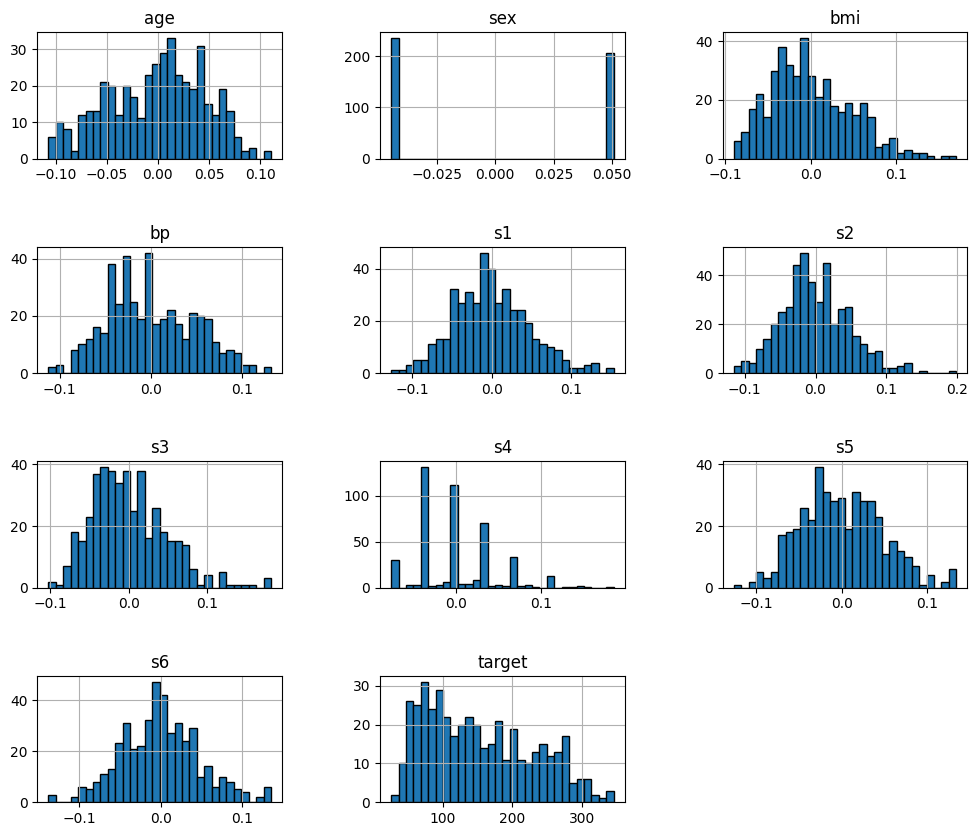

In [12]:
diabetes_dataset.frame.hist(figsize=(12, 10), bins=30, edgecolor="black")
plt.subplots_adjust(hspace=0.7, wspace=0.4)

In [13]:
features_of_interests = ["age",	"sex", "bmi", "bp",	"s1", "s2", "s3", "s4", "s5","s6"]
diabetes_dataset.frame.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [14]:
x_data, y_data = diabetes_dataset.data , diabetes_dataset.target

x_train, x_test, y_train, y_test = model_selection.train_test_split(x_data, y_data, test_size=0.2, random_state=42)

print(f"Training Features set : {x_train.shape}")
print(f"Testing Features set : {x_test.shape}")
print(f"Trainng Targets set : {y_train.shape}")
print(f"Testing Targets set : {y_test.shape}")



Training Features set : (353, 10)
Testing Features set : (89, 10)
Trainng Targets set : (353,)
Testing Targets set : (89,)


In [15]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [16]:
import numpy as np

y_predict = model.predict(x_test)

# Calculate RES
# df = number test of samples(n) - number of featues(p) -1
n = len(y_test)
print(f"Number of test samples: {n}")
p = x_test.shape[1]
print(f"Number of features: {p}")

df = n - p -1
print(f"Degree of freedom : {df}")

rss = np.sqrt((np.sum((y_test-y_predict)**2)/(df)))

mse = mean_squared_error(y_test, y_predict)

r2_stat = r2_score(y_test, y_predict)

print(f"Residual Standard Error : {rss:.2f}")
print(f"Mean Squred Error : {mse:.2f}")
print(f"R2 Statistic : {r2_stat:.2f}")



Number of test samples: 89
Number of features: 10
Degree of freedom : 78
Residual Standard Error : 57.53
Mean Squred Error : 2900.19
R2 Statistic : 0.45


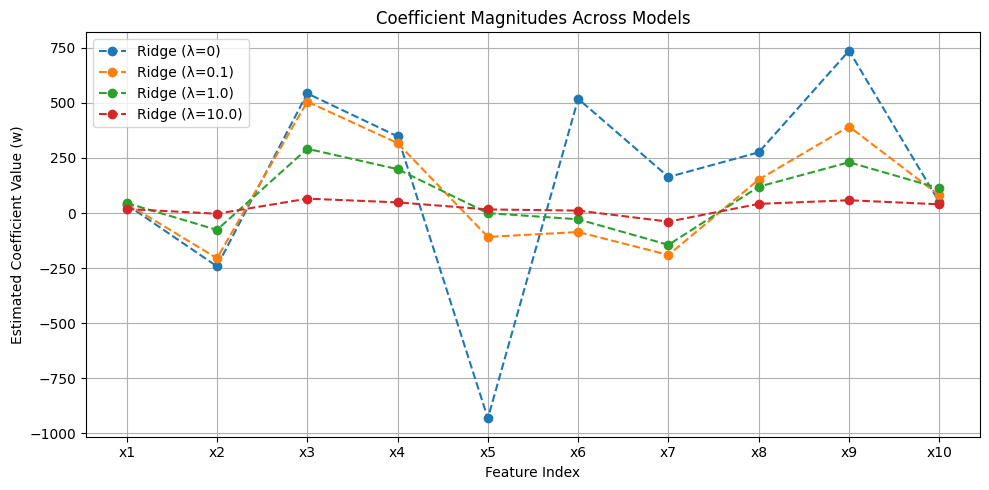

In [17]:
from scipy.optimize import ridder
from sklearn import linear_model
from sklearn.linear_model import Ridge

# lamda = 0.1, 1.0, 10.0
lamda = [0, 0.1, 1.0, 10.0]
coefs = {}


for lmd in lamda:
  rigde = Ridge(alpha=lmd)
  rigde.fit(x_train, y_train)
  coefs[lmd] = rigde.coef_

# plot
feature_indices = np.arange(x_train.shape[1])

plt.figure(figsize=(10, 5))
for lmd in lamda:
    plt.plot(
        feature_indices,
        coefs[lmd],
        "o--",
        label=f"Ridge (λ={lmd})",
    )

plt.xlabel("Feature Index")
plt.ylabel("Estimated Coefficient Value (w)")
plt.title("Coefficient Magnitudes Across Models")
plt.xticks(feature_indices, [f"x{i+1}" for i in feature_indices])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()